##Day4

In [1]:
from model_service import load_model_once, predict_proba_from_model

## 서빙 경로 복잡도 — `predict_proba_from_model`

기호: `n` = 요청 행 수, `d` = 특성 수 (모델이 고정, 이 모델은 `d = 30`)

| 단계 | 하는 일 | 복잡도 |
|---|---|---|
| 열 재배열 | `[c for c in names if c not in df.columns]` 없는 열 찾기 → `O(d)`<br>`df[names]` 모델 순서로 재배열(값 복사) → `O(n·d)` | **`O(n·d)`** |
| 스케일링 | `(sorted_df - mean) / scale` — 원소마다 뺄셈·나눗셈 | **`O(n·d)`** |
| 확률 계산 | `to_numpy` `O(n·d)` + `@ coefficients` `O(n·d)` + `+ intercept` `O(n)` + `sigmoid` `O(n)` | **`O(n·d)`** |
| **전체** | 상수배 흡수 + 낮은 차수 흡수 | **`O(n·d)`** |

**① 열 재배열이 `O(d²)`가 아닌 이유** — `df.columns`는 리스트가 아니라 `pd.Index`이고 내부 해시테이블로 조회하므로 1회 조회가 평균 `O(1)`. 리스트였다면 `d`번의 선형 탐색이 되어 이 단계가 `O(d²)`가 된다. 계획서가 경고한 함정이고, 확인 결과 해당 없음.

**② `+ intercept`와 `sigmoid`가 `O(n)`인 이유** — `(n,d) @ (d,) → (n,)`. 행렬-벡터 곱에서 `d`축이 축약되어 사라지므로, 그 뒤 연산은 전부 길이 `n`인 1차원 배열 위에서 돈다. (`sigmoid` 내부는 `astype`·마스크 2개·`exp` 2개로 전체 순회가 대여섯 번 돌지만 상수 배수일 뿐 차수가 아니다.)

**③ 요청 단위 복잡도** — `d`는 모델이 고정하므로 요청마다 변하지 않는다.

```
O(n·d)  →  d 고정  →  O(n)
→ 로그-로그 그래프에서 큰 n 구간의 기울기 예측 = 1
```

**④ 측정에 섞이는 상수항** — 실제로 재면 `T(n) = a + b·n` 꼴이다. `a`는 파이썬 호출 오버헤드, pandas 객체 조립, `pd.Index` 해시테이블 빌드(`O(d)`) 등 `n`과 무관한 비용. 작은 `n`에서는 `a`가 `b·n`을 가리므로 **로그-로그 그래프의 왼쪽 끝은 평평할 것으로 예상**된다.


n: 1 → 10000 (1만 배)  →  
① warm-up 없이:  1만 배보다 작다
② warm-up 후:    1만 배에 가깝다

로그-로그 왼쪽 끝 모양: 평평     오른쪽 끝 기울기: 올라감

In [2]:
import time
import pandas as pd

In [3]:
def time_predict(model: dict, df, repeat: int = 5) -> float:
    """
    predict_proba_from_model 1회 호출 시간의 중앙값을 초 단위로 반환한다.

    model: load_model_once 의 반환값.
    df:    예측할 입력 DataFrame (행 수 = n).
    repeat: 측정 반복 횟수. 중앙값을 쓴다.
    반환:  1회 호출 시간의 중앙값(초).

    설계 결정 2개 — 고른 쪽과 이유를 각각 한 줄씩 노트북에 적을 것:
      (1) time.perf_counter 와 timeit 중 무엇을 쓰는가
      (2) 타이머 밖 warm-up 호출을 두는가 / 중앙값만으로 충분한가
    """
    times = []
    t0 = time.perf_counter()
    for i in range(repeat):
        value = predict_proba_from_model(model, df)
        t = time.perf_counter()
        times.append(t-t0)
        t0 = time.perf_counter()
    times.sort()
    result = times[len(times)//2]

    return result

model = load_model_once("model.json")
cols = model['feature_names']
df = pd.DataFrame(0, index=range(1000000), columns=cols)
n_rows = [1,10,100,1000,10000,100000,1000000]
median_times = []
for i in range(len(n_rows)):
    median_times.append(time_predict(model,df.head(n_rows[i])))
print(median_times)

[0.000439800089225173, 0.00040670018643140793, 0.0006928001530468464, 0.00043809995986521244, 0.00404640007764101, 0.04023270006291568, 0.38381129992194474]


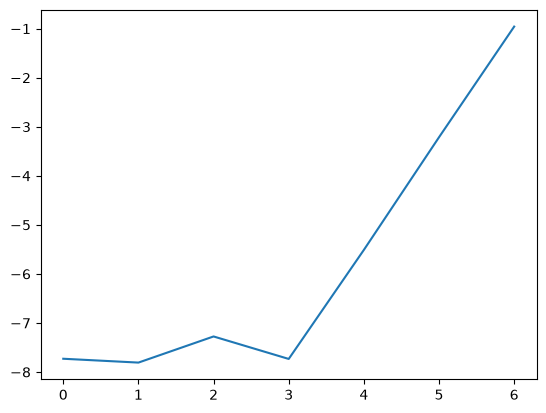

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

n = np.array(n_rows)
t = np.array(median_times)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n, t, marker='o', label='측정')          # ← 축 둘 다 로그

# 기울기 1 기준선 — 마지막 점을 지나게 맞춘다
ax.loglog(n, t[-1] * n / n[-1], '--', label='기울기 1')

ax.set_xlabel('n (행 수)')
ax.set_ylabel('호출 시간 (s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

In [5]:
def time_predict(model: dict, df, repeat: int = 5) -> float:
    """
    predict_proba_from_model 1회 호출 시간의 중앙값을 초 단위로 반환한다.

    model: load_model_once 의 반환값.
    df:    예측할 입력 DataFrame (행 수 = n).
    repeat: 측정 반복 횟수. 중앙값을 쓴다.
    반환:  1회 호출 시간의 중앙값(초).

    설계 결정 2개 — 고른 쪽과 이유를 각각 한 줄씩 노트북에 적을 것:
      (1) time.perf_counter 와 timeit 중 무엇을 쓰는가
      (2) 타이머 밖 warm-up 호출을 두는가 / 중앙값만으로 충분한가
    """
    value = predict_proba_from_model(model, df)
    times = []
    t0 = time.perf_counter()
    for i in range(repeat):
        value = predict_proba_from_model(model, df)
        t = time.perf_counter()
        times.append(t-t0)
        t0 = time.perf_counter()
    times.sort()
    result = times[len(times)//2]
    return result

model = load_model_once("model.json")
cols = model['feature_names']
df = pd.DataFrame(0, index=range(1000000), columns=cols)
n_rows = [1,10,100,1000,10000,100000,1000000]
median_times = []
for i in range(len(n_rows)):
    median_times.append(time_predict(model,df.head(n_rows[i])))
print(median_times)

[0.0004408999811857939, 0.0004639001563191414, 0.00041690003126859665, 0.0004656000528484583, 0.004302500048652291, 0.03779809991829097, 0.38739600009284914]


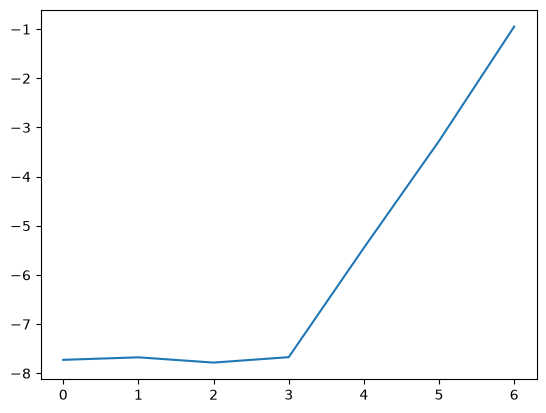

In [ ]:
n = np.array(n_rows)
t = np.array(median_times)

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(n, t, marker='o', label='측정')          # ← 축 둘 다 로그

# 기울기 1 기준선 — 마지막 점을 지나게 맞춘다
ax.loglog(n, t[-1] * n / n[-1], '--', label='기울기 1')

ax.set_xlabel('n (행 수)')
ax.set_ylabel('호출 시간 (s)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()

## 설계 결정

**(1) `time.perf_counter` 채택** — `timeit`과 같은 시계를 쓰므로 해상도 차이는 없고, 둘의 차이는 반복 횟수·통계·GC를 누가 통제하느냐다. 측정 구간이 0.4ms~384ms로 호출 오버헤드에 묻히지 않는 규모라 `timeit`의 루프 희석이 불필요했고, 계획서가 지정한 "5회 중앙값"을 직접 통제하려고 `perf_counter`를 골랐다. `timeit`은 기본으로 GC를 끄는데 그건 실제 서빙 조건과 다르다는 점도 고려했다.

**(2) warm-up — 두 버전을 모두 측정** — 정렬 후 중앙값이 1회차 오염을 이미 걸러주므로(5개 중 1개가 튀어도 3번째 값은 안 바뀐다) warm-up은 중복 안전장치다. 효과를 확인하려고 타이머 밖 호출이 **없는** 버전과 **있는** 버전을 따로 측정했다.

## 측정 결과

| n | warm-up 無 | 기울기 | warm-up 有 | 기울기 |
|---:|---:|---:|---:|---:|
| 1 | 0.440 ms | — | 0.441 ms | — |
| 10 | 0.407 | −0.03 | 0.464 | +0.02 |
| 100 | 0.693 | +0.23 | 0.417 | −0.05 |
| 1,000 | 0.438 | −0.20 | 0.466 | +0.05 |
| 10,000 | 4.046 | +0.97 | 4.303 | +0.97 |
| 100,000 | 40.23 | +1.00 | 37.80 | +0.94 |
| 1,000,000 | 383.8 | +0.98 | 387.4 | +1.01 |

**완료 기준 충족** — 큰 `n` 구간(10⁴→10⁶)의 기울기가 양쪽 모두 0.94~1.01. 표에서 예측한 요청 단위 `O(n)`과 일치한다.

**warm-up 효과: 관측되지 않음.** 두 열의 차이가 같은 조건 안의 산포(작은 `n`에서 0.41~0.69ms)보다 작다. 정렬 중앙값이 1회차 오염을 이미 걸러낸다는 판단을 지지하는 결과다. 단, 두 셀을 같은 커널에서 순차 실행했으므로 뒤쪽 셀도 데워진 상태다 — "차이가 없다"는 이 조건 아래의 결론이다.

**상수항 추정** — 큰 `n` 두 점으로 `T(n) = a + b·n`을 맞추면 `b ≈ 0.38 µs/행`. `n ≤ 1000` 구간이 평평한 데서 `a ≈ 0.44 ms`. 교차점(`a = b·n`)은 `n ≈ 1,000`대이고, 실제로 기울기가 1에 닿는 것은 그보다 한 자릿수 위인 `n = 10⁴`부터다.

**예상 대조**

| 예상 | 결과 |
|---|---|
| 왼쪽 끝 평평 | ✅ `n ≤ 1000`에서 기울기 ≈ 0 |
| 오른쪽 끝 기울기 1 | ✅ 10⁴ 이상에서 0.94~1.01 |
| 비율 1만 배 (warm-up 후) | ❌ `n=10⁶`에서 873배. `a`는 1회성 비용이 아니라 **매 호출 고정비**라 warm-up으로 제거되지 않는다 |

비율이 1만 배가 되려면 `b·n ≈ 10⁴ · a`, 즉 `n ≈ 1.2 × 10⁷`. 30열 float64로 약 2.8GB라 이 PC에서는 측정할 수 없다. **기울기 ≈ 1(10⁴부터)과 비율 1만 배(10⁷ 자리)는 서로 다른 질문**이고, 완료 기준은 전자다.
